In [62]:
import pandas as pd
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv(r"superstore_dataset\train.csv", encoding='latin1')

print("\nDataset Loaded Successfully\n")
print(df.head())


Dataset Loaded Successfully

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Regio

In [82]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [84]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

In [86]:
df = df.drop_duplicates()

In [88]:
total_sales = df['Sales'].sum()
print("Total Revenue:", total_sales)

Total Revenue: 2261536.7827000003


In [90]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 4922


In [92]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\nRevenue by Category:\n", category_sales)


Revenue by Category:
 Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [94]:
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
print("\nTop Sub-Categories:\n", sub_sales)


Top Sub-Categories:
 Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64


In [96]:
top_customers = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False).head(10)
print("\nTop Customers:\n", top_customers)


Top Customers:
 Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
Name: Sales, dtype: float64


In [98]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("\nRegion Performance:\n", region_sales)


Region Performance:
 Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [100]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
print("\nMonthly Trend:\n", monthly_sales.head())


Monthly Trend:
    Year     Month       Sales
0  2015     April  27906.8550
1  2015    August  27117.5365
2  2015  December  68167.0585
3  2015  February   4519.8920
4  2015   January  14205.7070


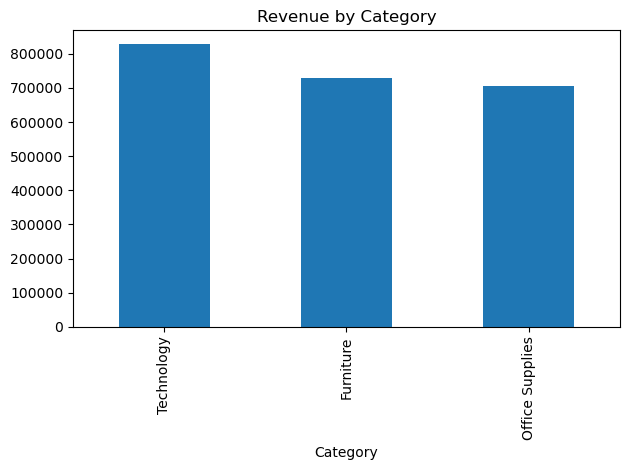

In [102]:
category_sales.plot(kind='bar', title='Revenue by Category')
plt.tight_layout()
plt.show()

In [106]:
df.to_csv("cleaned_sales_data1.csv", index=False)